# Spotify Song Clustering - Improved Version

This notebook is a cleaner version of the original exploratory project in `ML_spotify_5000_online.ipynb`.

The goal is still simple: group Spotify tracks into clusters using audio features. The improvements are focused on readability, reproducibility, and clearer cluster selection.

## Improvements Compared With the Original Notebook

- Keeps the original dataset and general workflow.
- Uses named constants for important settings.
- Sets `random_state` and `n_init` for reproducible KMeans results.
- Evaluates cluster counts with inertia, silhouette score, and maximum cluster size.
- Selects the final cluster count using both quality and the 250-song size target.
- Adds cluster profiles and representative songs nearest to each cluster center.

## 1. Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")

## 2. Configuration

In [13]:
DATA_URL = "https://drive.google.com/file/d/1YDT730_iSTcxjgebGQAhFcczpBQu9jNs/view?usp=share_link"
RANDOM_STATE = 42
MAX_CLUSTER_SIZE = 250
K_MIN = 20
K_MAX = 100

DROP_COLUMNS = [
    "type",
    "duration_ms",
    "time_signature",
    "id",
    "html",
    "mode",
    "liveness",
]

## 3. Load Data

In [14]:

path = "https://drive.google.com/uc?export=download&id="+DATA_URL.split("/")[-2]
music_raw = pd.read_csv(path, sep =",")

music_raw.head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


## 4. Clean and Prepare Features

In [15]:
def prepare_music_data(df):
    music = df.copy()
    music.columns = music.columns.str.replace(" ", "")

    required_columns = {"artist", "name"}
    missing_columns = required_columns - set(music.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    music = music.drop(columns=DROP_COLUMNS, errors="ignore")
    music = music.set_index(["artist", "name"])

    feature_data = music.apply(pd.to_numeric, errors="coerce")
    feature_data = feature_data.dropna()

    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(feature_data)

    scaled_music = pd.DataFrame(
        scaled_values,
        columns=feature_data.columns,
        index=feature_data.index,
    )

    return scaled_music, feature_data, scaler


scaled_music, feature_data, scaler = prepare_music_data(music_raw)

print(f"Rows used for clustering: {len(scaled_music):,}")
print(f"Features used: {list(scaled_music.columns)}")
scaled_music.head()

Rows used for clustering: 5,235
Features used: ['danceability', 'energy', 'key', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo']


,,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,valence,tempo
artist,name,,,,,,,,,
Gilberto Gil,Se Eu Quiser Falar Com Deus,0.680455,0.2590,1.000000,0.763897,0.076797,0.696787,0.000060,0.310660,0.515800
Antônio Carlos Jobim,Saudade De Bahia,0.767322,0.3990,0.181818,0.771967,0.037691,0.217871,0.000002,0.703553,0.584322
Martinho Da Vila,"Canta Canta, Minha Gente",0.880041,0.7300,0.181818,0.798018,0.377996,0.454819,0.000064,0.918782,0.437862
Chico César,Mulher Eu Sei,0.729059,0.0502,0.363636,0.682811,0.051307,0.882530,0.000041,0.531980,0.499098
Kurt Elling,Rosa Morena,0.673216,0.1190,0.545455,0.655228,0.041394,0.919679,0.000348,0.408122,0.565171


## 5. Evaluate Cluster Counts

The original project selected 36 clusters after reviewing inertia and silhouette plots. This version also checks whether each `k` keeps every cluster at or below the target size of 250 songs.

In [5]:
def evaluate_kmeans_range(data, k_min=20, k_max=100):
    rows = []

    for k in range(k_min, k_max + 1):
        if k >= len(data):
            continue

        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=20,
        )
        labels = model.fit_predict(data)
        cluster_sizes = pd.Series(labels).value_counts()

        rows.append(
            {
                "k": k,
                "inertia": model.inertia_,
                "silhouette_score": silhouette_score(data, labels),
                "max_cluster_size": int(cluster_sizes.max()),
                "min_cluster_size": int(cluster_sizes.min()),
                "cluster_size_std": float(cluster_sizes.std()),
                "meets_size_target": bool(cluster_sizes.max() <= MAX_CLUSTER_SIZE),
            }
        )

    return pd.DataFrame(rows)


evaluation = evaluate_kmeans_range(scaled_music, K_MIN, K_MAX)
evaluation.head()

,k,inertia,silhouette_score,max_cluster_size,min_cluster_size,cluster_size_std,meets_size_target
0,20,608.110225,0.203098,430,74,108.805415,False
1,21,598.532748,0.187612,418,78,88.752545,False
2,22,587.567488,0.187798,396,72,75.663715,False
3,23,577.361001,0.198298,388,74,87.123600,False
4,24,571.091838,0.199595,425,74,89.265268,False


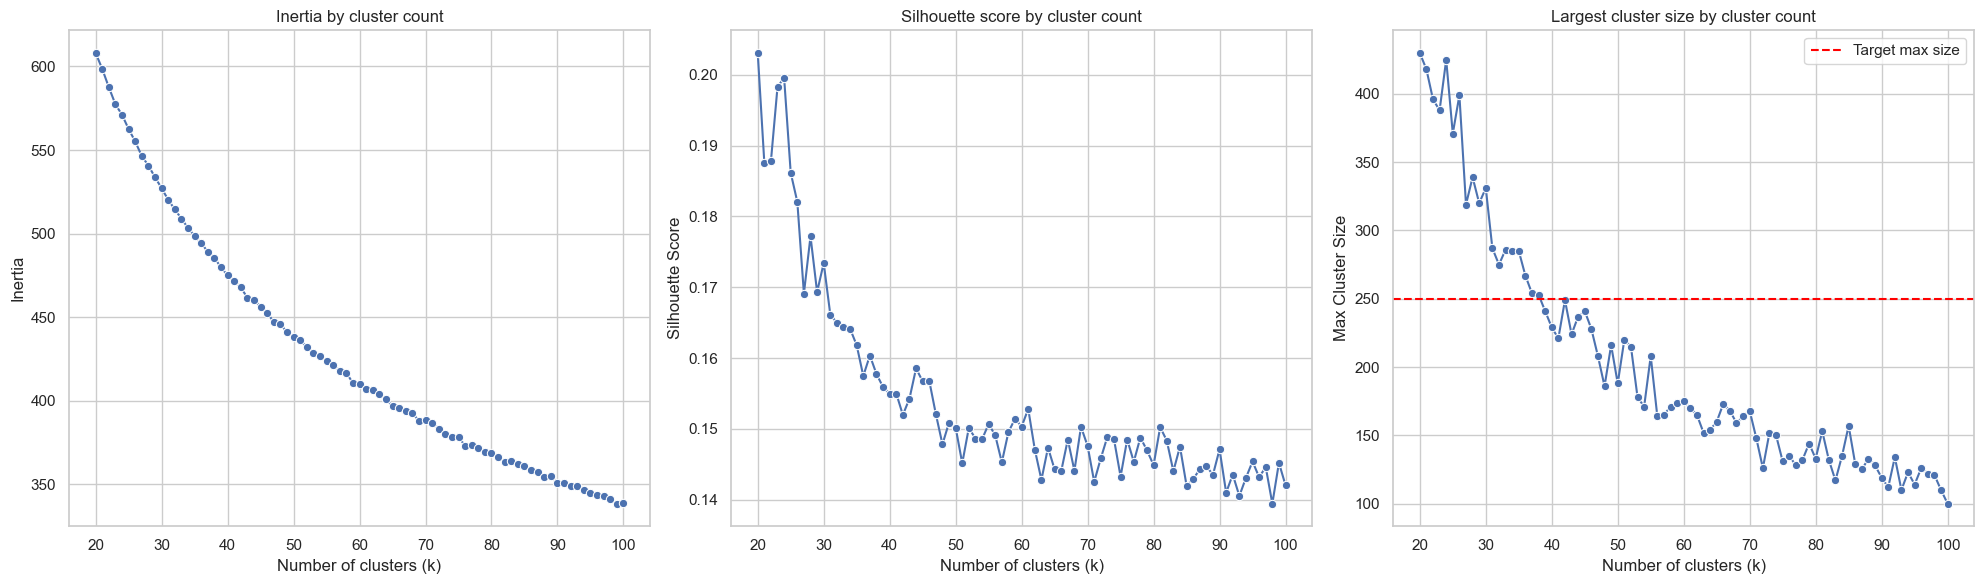

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.lineplot(data=evaluation, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Inertia by cluster count")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=evaluation, x="k", y="silhouette_score", marker="o", ax=axes[1])
axes[1].set_title("Silhouette score by cluster count")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

sns.lineplot(data=evaluation, x="k", y="max_cluster_size", marker="o", ax=axes[2])
axes[2].axhline(MAX_CLUSTER_SIZE, color="red", linestyle="--", label="Target max size")
axes[2].set_title("Largest cluster size by cluster count")
axes[2].set_xlabel("Number of clusters (k)")
axes[2].set_ylabel("Max Cluster Size")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Choose Final Cluster Count

This rule keeps the project simple:

1. Prefer cluster counts where every cluster has at most 250 songs.
2. Among those, choose the highest silhouette score.
3. If no cluster count meets the size target, choose the highest silhouette score and report the limitation.

In [27]:
valid_candidates = evaluation[evaluation["meets_size_target"]]

if len(valid_candidates) > 0:
    selected_row = valid_candidates.sort_values("silhouette_score", ascending=False).iloc[0]
    selection_note = "Selected from cluster counts that meet the 250-song size target."
else:
    selected_row = evaluation.sort_values("silhouette_score", ascending=False).iloc[0]
    selection_note = "No evaluated cluster count met the 250-song size target. Selected best silhouette score instead."

selected_k = int(selected_row["k"])

print(selection_note)
print(f"Selected k: {selected_k}")
selected_row.to_frame().T

Selected from cluster counts that meet the 250-song size target.
Selected k: 44


,k,inertia,silhouette_score,max_cluster_size,min_cluster_size,cluster_size_std,meets_size_target
24,44,460.369736,0.158528,237,45,47.054886,True


For comparison, the original notebook used `k=36`. The table below shows how that choice performs under the clearer evaluation rule.

In [8]:
evaluation[evaluation["k"] == 36]

,k,inertia,silhouette_score,max_cluster_size,min_cluster_size,cluster_size_std,meets_size_target
16,36,494.252258,0.157465,267,57,52.898488,False


## 7. Train Final Model

In [28]:
final_model = KMeans(
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=20,
)

clustered_music = scaled_music.copy()
clustered_music["cluster"] = final_model.fit_predict(scaled_music)

clustered_music["cluster"].value_counts().sort_index().to_frame("song_count").T

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
song_count,104,80,237,204,113,83,96,147,105,156,...,127,194,117,182,59,113,110,75,125,81


## 8. Cluster Profiles

Cluster profiles show the average scaled audio features for each group. These make the clusters easier to interpret.

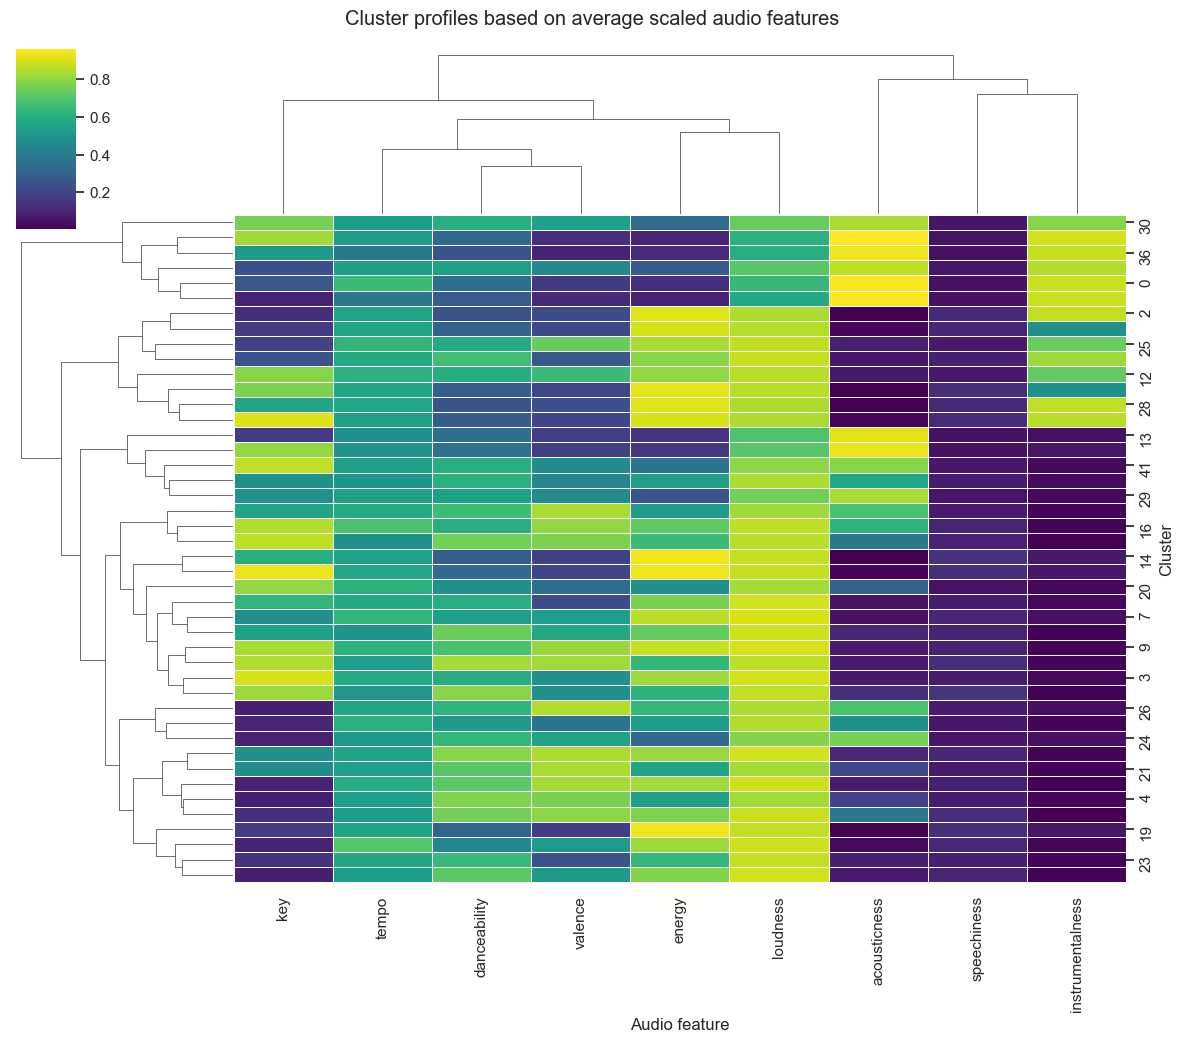

,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,valence,tempo
cluster,,,,,,,,,
0,0.351896,0.135369,0.260490,0.640433,0.048125,0.946304,0.879149,0.166325,0.649988
1,0.514633,0.528838,0.105682,0.846470,0.063069,0.487726,0.012965,0.365028,0.613562
2,0.241815,0.909958,0.120829,0.838803,0.115124,0.004564,0.868603,0.222070,0.568045
3,0.594628,0.817162,0.898841,0.890119,0.079851,0.069456,0.023832,0.472798,0.589791
4,0.771833,0.535708,0.086082,0.823808,0.076452,0.190973,0.018001,0.762553,0.537981


In [51]:
cluster_profiles = clustered_music.groupby("cluster").mean()

g = sns.clustermap(
    cluster_profiles,
    cmap="viridis",
    linewidths=0.5,
    figsize=(12, 10)
)

g.fig.suptitle("Cluster profiles based on average scaled audio features", y=1.02)
g.ax_heatmap.set_xlabel("Audio feature")
g.ax_heatmap.set_ylabel("Cluster")
plt.show()

cluster_profiles.head()

## 9. Representative Songs

Instead of only taking random samples, this section finds songs closest to each cluster center. These are useful examples of what each cluster represents.

In [11]:
def representative_songs(data_with_clusters, model, songs_per_cluster=5):
    rows = []
    feature_columns = data_with_clusters.drop(columns="cluster").columns

    for cluster_id in sorted(data_with_clusters["cluster"].unique()):
        cluster_data = data_with_clusters[data_with_clusters["cluster"] == cluster_id]
        distances = pairwise_distances(
            cluster_data[feature_columns],
            model.cluster_centers_[[cluster_id]],
        ).ravel()

        nearest_positions = np.argsort(distances)[:songs_per_cluster]

        for position in nearest_positions:
            artist, name = cluster_data.index[position]
            rows.append(
                {
                    "cluster": int(cluster_id),
                    "artist": artist,
                    "name": name,
                    "distance_to_center": float(distances[position]),
                }
            )

    return pd.DataFrame(rows)


representatives = representative_songs(clustered_music, final_model, songs_per_cluster=5)
representatives.head(20)

,cluster,artist,name,distance_to_center
0,0,Wolfgang Amadeus Mozart,"Le nozze di Figaro, K.492: Overture ...",0.135454
1,0,Sia Furler,Helium - Piano Version ...,0.143061
2,0,Chihei Hatakeyama,Ferrum ...,0.157568
3,0,Lavinia Meijer,I Giorni ...,0.168304
4,0,Felix Mendelssohn,"Overture to A Midsummer Night's Dream, Op.21 ...",0.175780
5,1,Yvonne Catterfeld,Erinner mich dich zu vergessen - Radio Version...,0.142487
6,1,East 17,Stay Another Day ...,0.159441
7,1,George Michael,Don't Let the Sun Go Down on Me ...,0.173072
8,1,Flume,Never Be Like You ...,0.184306
9,1,Joe Cocker,Up Where We Belong ...,0.192001


### Representative Song Distances

Each point below is one representative song. Lower distance means the song is closer to the center of its cluster.

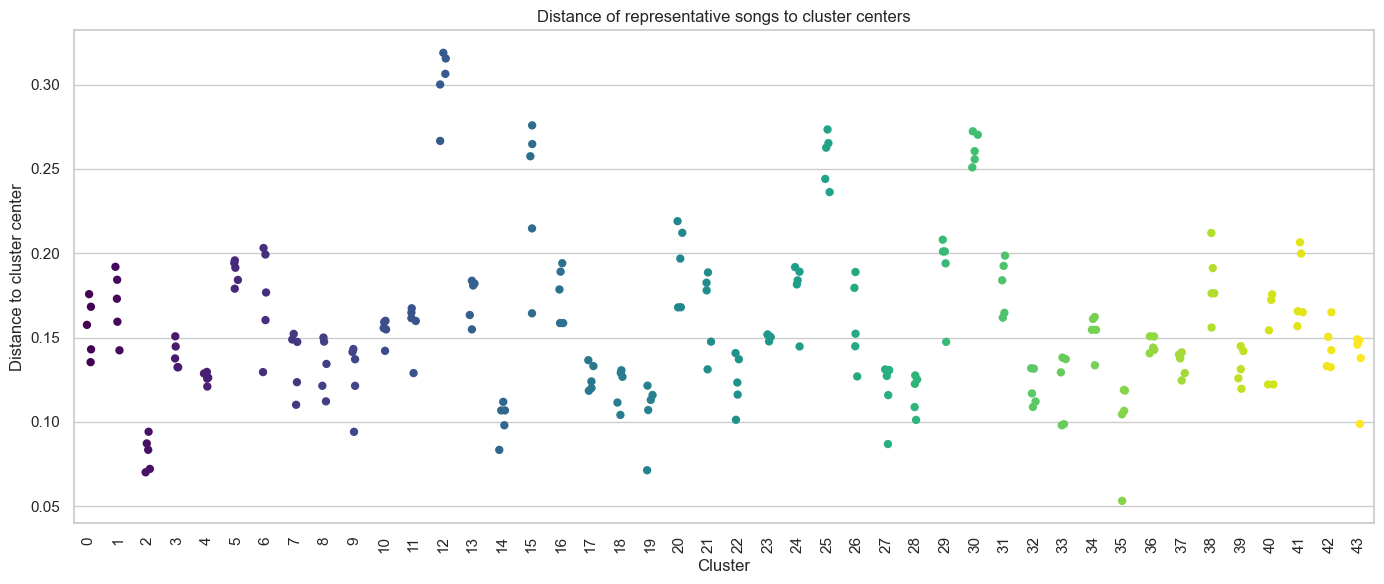

In [41]:
plt.figure(figsize=(14, 6))

sns.stripplot(
    data=representatives,
    x="cluster",
    y="distance_to_center",
    hue="cluster",
    palette="viridis",
    legend=False,
    size=6,
)

plt.title("Distance of representative songs to cluster centers")
plt.xlabel("Cluster")
plt.ylabel("Distance to cluster center")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 10. Conclusion

This improved notebook keeps the original project idea but makes the modelling choice more transparent. The most important improvement is that the final cluster count is now selected using both clustering quality and the practical target of keeping clusters under 250 songs.

Possible next steps would be to compare different feature sets, add genre labels if available, or turn the cluster output into a simple song recommendation tool.